# Gun Dataset Exploration and YOLO26 Training

This notebook explores the `Gun.v2i.yolo26` dataset, trains a YOLO26 object detector for the `gun` class, and evaluates the trained model on the held-out test split.


In [1]:
%pip install -U ultralytics pyyaml

from pathlib import Path
import random

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import yaml

DATASET_ROOT_CANDIDATES = [
    Path("data/Gun.v2i.yolo26"),
    Path("Gun.v2i.yolo26"),
]
DATASET_ROOT = next((p for p in DATASET_ROOT_CANDIDATES if p.exists()), DATASET_ROOT_CANDIDATES[0])
CONFIG_PATH = DATASET_ROOT / "data.yaml"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {CONFIG_PATH}. Expected the Roboflow export under one of: "
        f"{[str(p) for p in DATASET_ROOT_CANDIDATES]}"
    )

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg.get("names", [])
num_classes = data_cfg.get("nc", len(class_names))

# Roboflow exports can contain paths such as ../train/images. For this repo layout,
# write a local Ultralytics config with a fixed dataset root and split-relative paths.
YOLO_DATA_CONFIG_PATH = DATASET_ROOT / "data_yolo26_local.yaml"
yolo_data_cfg = {
    "path": str(DATASET_ROOT.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": num_classes,
    "names": class_names,
}
with open(YOLO_DATA_CONFIG_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(yolo_data_cfg, f, sort_keys=False)

print("Dataset root:", DATASET_ROOT.resolve())
print("Source data config:", CONFIG_PATH.resolve())
print("Ultralytics data config:", YOLO_DATA_CONFIG_PATH.resolve())
print("Classes:", class_names)
print("Number of classes:", num_classes)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Dataset root: /Users/gubscruz/INSPER/7_PERIODO/computer-vision/cv-gun-detection/data/Gun.v2i.yolo26
Source data config: /Users/gubscruz/INSPER/7_PERIODO/computer-vision/cv-gun-detection/data/Gun.v2i.yolo26/data.yaml
Ultralytics data config: /Users/gubscruz/INSPER/7_PERIODO/computer-vision/cv-gun-detection/data/Gun.v2i.yolo26/data_yolo26_local.yaml
Classes: ['gun']
Number of classes: 1


In [2]:
SPLITS = ["train", "valid", "test"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_images(split):
    image_dir = DATASET_ROOT / split / "images"
    if not image_dir.exists():
        return []
    return sorted([p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])

def label_for_image(image_path):
    label_dir = image_path.parent.parent / "labels"
    return label_dir / f"{image_path.stem}.txt"

def parse_yolo_label(label_path):
    rows = []
    if not label_path.exists():
        return rows

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, x_c, y_c, w, h = parts
            rows.append({
                "class_id": int(float(cls_id)),
                "x_center": float(x_c),
                "y_center": float(y_c),
                "width": float(w),
                "height": float(h),
                "area": float(w) * float(h),
            })
    return rows


In [3]:
split_rows = []
annotation_rows = []

for split in SPLITS:
    images = list_images(split)
    image_count = len(images)
    labeled_images = 0
    boxes_count = 0

    for img in images:
        label_path = label_for_image(img)
        boxes = parse_yolo_label(label_path)
        if boxes:
            labeled_images += 1
            boxes_count += len(boxes)
            for b in boxes:
                annotation_rows.append({
                    "split": split,
                    "image": img.name,
                    **b
                })

    split_rows.append({
        "split": split,
        "images": image_count,
        "images_with_labels": labeled_images,
        "boxes": boxes_count
    })

split_df = pd.DataFrame(split_rows)
ann_df = pd.DataFrame(annotation_rows)

display(split_df)
print("Total boxes:", len(ann_df))


,split,images,images_with_labels,boxes
0,train,12207,12207,13106
1,valid,3518,3518,3837
2,test,1744,1744,1864


Total boxes: 18807


              width        height          area
count  18807.000000  18807.000000  18807.000000
mean       0.289259      0.393919      0.180248
std        0.287886      0.274997      0.279158
min        0.006250      0.030469      0.000498
25%        0.089844      0.175000      0.016598
50%        0.166406      0.314844      0.052324
75%        0.360938      0.542969      0.183040
max        1.000000      1.000000      1.000000


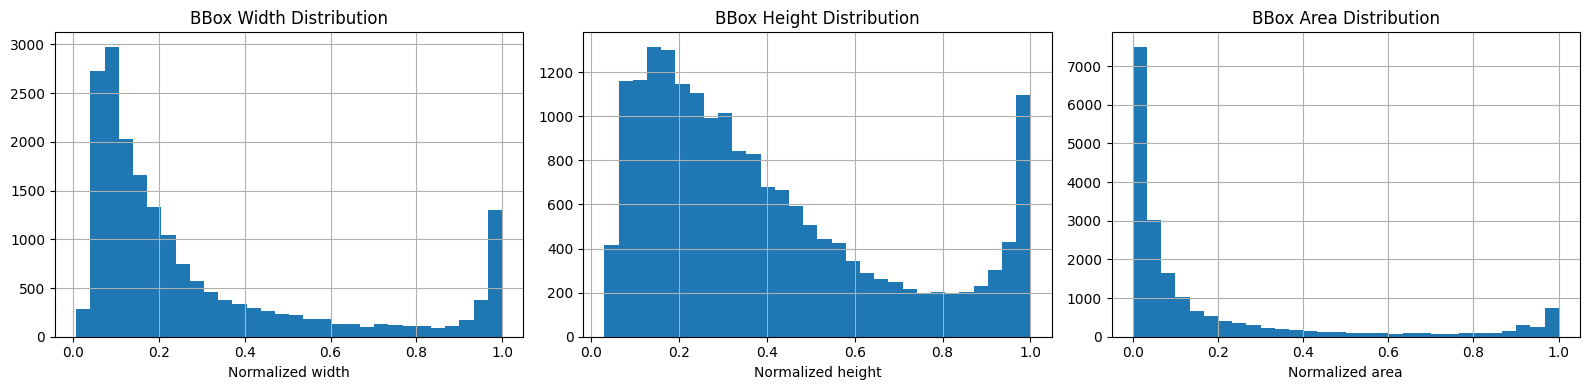

In [4]:
if ann_df.empty:
    print("No annotations available for bounding-box distribution plots.")
else:
    print(ann_df[["width", "height", "area"]].describe())

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ann_df["width"].hist(ax=axes[0], bins=30)
    axes[0].set_title("BBox Width Distribution")
    axes[0].set_xlabel("Normalized width")

    ann_df["height"].hist(ax=axes[1], bins=30)
    axes[1].set_title("BBox Height Distribution")
    axes[1].set_xlabel("Normalized height")

    ann_df["area"].hist(ax=axes[2], bins=30)
    axes[2].set_title("BBox Area Distribution")
    axes[2].set_xlabel("Normalized area")

    plt.tight_layout()
    plt.show()


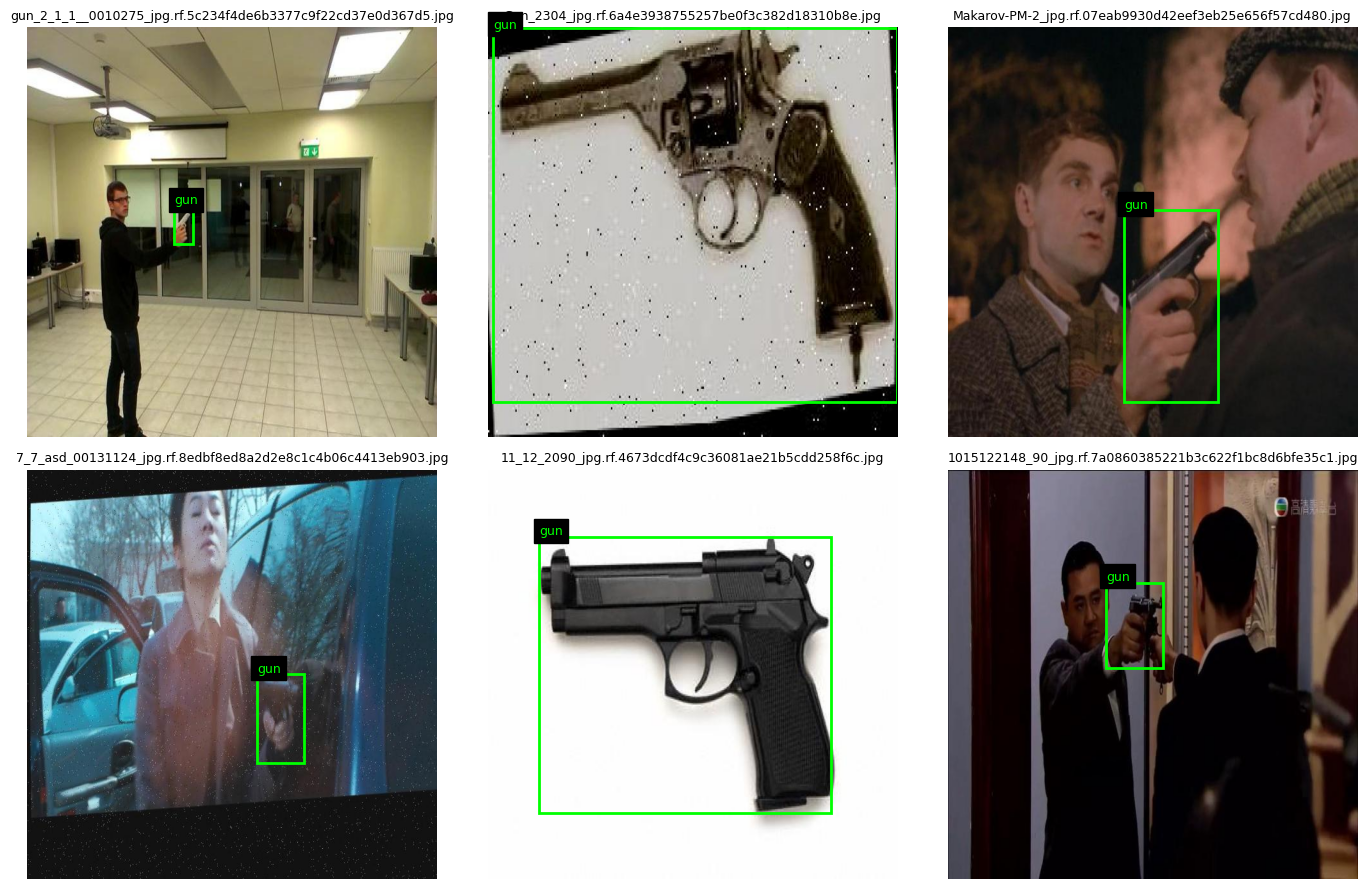

In [5]:
def draw_yolo_boxes(ax, image_shape, boxes):
    h, w = image_shape[0], image_shape[1]
    for b in boxes:
        x_center = b["x_center"] * w
        y_center = b["y_center"] * h
        bw = b["width"] * w
        bh = b["height"] * h

        x0 = x_center - bw / 2
        y0 = y_center - bh / 2

        rect = patches.Rectangle((x0, y0), bw, bh, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)

        cls_id = b["class_id"]
        cls_name = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
        ax.text(x0, max(0, y0 - 4), cls_name, color="lime", fontsize=9, backgroundcolor="black")

sample_split = "train"
sample_images = list_images(sample_split)

if not sample_images:
    print(f"No images found for split: {sample_split}")
else:
    n = min(6, len(sample_images))
    chosen = random.sample(sample_images, n)

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.flatten()

    for ax, img_path in zip(axes, chosen):
        img = plt.imread(img_path)
        label_path = label_for_image(img_path)
        boxes = parse_yolo_label(label_path)

        ax.imshow(img)
        draw_yolo_boxes(ax, img.shape, boxes)
        ax.set_title(img_path.name, fontsize=9)
        ax.axis("off")

    for ax in axes[len(chosen):]:
        ax.axis("off")

    plt.tight_layout()


Tiny boxes (< 0.001 area): 11 (0.06%)
Large boxes (> 0.25 area): 3875 (20.60%)
Examples of tiny boxes:


,split,image,class_id,width,height,area
2406,train,11_12_910_jpg.rf.d4751cb9869fa7565f443992df1b2...,0,0.006250,0.079687,0.000498
4725,train,7_7_asd_00139524_jpg.rf.c474875142e9e55f1d0b24...,0,0.021094,0.039062,0.000824
4726,train,7_7_asd_00139524_jpg.rf.fe7d447e17b7d167dacfd5...,0,0.017969,0.032031,0.000576
4727,train,7_7_asd_00139530_jpg.rf.91f112af76f1df0e8dd980...,0,0.016406,0.033594,0.000551
4728,train,7_7_asd_00139538_jpg.rf.0f997c649789bd55be28be...,0,0.017188,0.030469,0.000524
4729,train,7_7_asd_00139538_jpg.rf.72324019b12f6bc4f38488...,0,0.021875,0.039062,0.000854
4730,train,7_7_asd_00139540_jpg.rf.0073e99700f02c0e38f768...,0,0.017188,0.032031,0.000551
4731,train,7_7_asd_00139540_jpg.rf.daf724707c2ad5ece909b3...,0,0.016406,0.030469,0.000500
4732,train,7_7_asd_00139542_jpg.rf.3baf80d1848fb44d67ef0c...,0,0.017969,0.032031,0.000576
4733,train,7_7_asd_00139542_jpg.rf.4a3bbe46d38b7d7d60dc6b...,0,0.020313,0.037500,0.000762


Examples of large boxes:


,split,image,class_id,width,height,area
0,train,00000011_jpg.rf.0ed9d19c8ed1076e249a23a5d34e32...,0,0.943750,0.764062,0.721084
1,train,00000011_jpg.rf.5e747100bc097d2d785b5346b0c2c1...,0,0.887500,0.382031,0.339053
2,train,00000038_jpg.rf.b3586679e13aa118b1bacff86f711b...,0,0.963281,0.873437,0.841366
3,train,00000071_jpg.rf.4a934a391756e622104ea8bed20a40...,0,0.951562,0.846875,0.805854
4,train,00000092_jpg.rf.ae34e8a0c089795802f29dd3409d6b...,0,0.963281,0.987500,0.951240
5,train,00000092_jpg.rf.ae34e8a0c089795802f29dd3409d6b...,0,0.963281,0.987500,0.951240
6,train,00000092_jpg.rf.c04145e8a1b67521cea9b236ddb24a...,0,0.920312,0.752344,0.692391
7,train,00000092_jpg.rf.c04145e8a1b67521cea9b236ddb24a...,0,0.920312,0.752344,0.692391
8,train,00000101_jpg.rf.14e3f5d8b1386202287466239e0a5c...,0,0.950000,0.275000,0.261250
9,train,00000101_jpg.rf.71e65bff4d2379a4a573bf3b72bc53...,0,0.954688,0.420312,0.401267


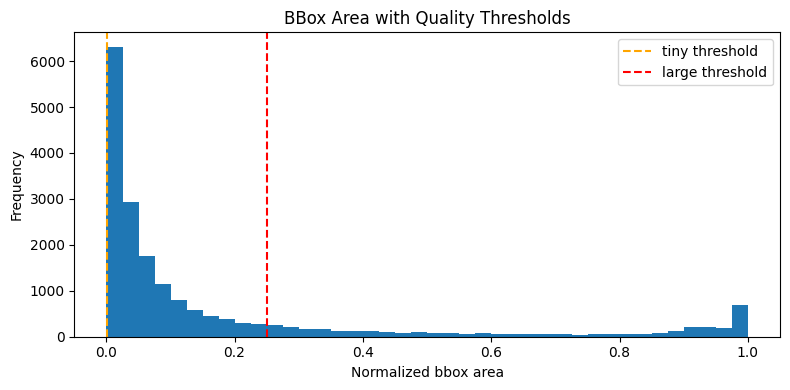

In [6]:
# quality checks for tiny and unusually large boxes
# Thresholds are on normalized area in [0, 1]
tiny_threshold = 0.001
large_threshold = 0.25

if ann_df.empty:
    print("No annotations available for box quality checks.")
else:
    tiny_boxes = ann_df[ann_df["area"] < tiny_threshold].copy()
    large_boxes = ann_df[ann_df["area"] > large_threshold].copy()

    total_boxes = len(ann_df)
    tiny_pct = 100 * len(tiny_boxes) / total_boxes
    large_pct = 100 * len(large_boxes) / total_boxes

    print(f"Tiny boxes (< {tiny_threshold} area): {len(tiny_boxes)} ({tiny_pct:.2f}%)")
    print(f"Large boxes (> {large_threshold} area): {len(large_boxes)} ({large_pct:.2f}%)")

    if not tiny_boxes.empty:
        print("Examples of tiny boxes:")
        display(tiny_boxes[["split", "image", "class_id", "width", "height", "area"]].head(10))

    if not large_boxes.empty:
        print("Examples of large boxes:")
        display(large_boxes[["split", "image", "class_id", "width", "height", "area"]].head(10))

    plt.figure(figsize=(8, 4))
    plt.hist(ann_df["area"], bins=40)
    plt.axvline(tiny_threshold, color="orange", linestyle="--", label="tiny threshold")
    plt.axvline(large_threshold, color="red", linestyle="--", label="large threshold")
    plt.title("BBox Area with Quality Thresholds")
    plt.xlabel("Normalized bbox area")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


,split,image,num_objects
count,17469,17469,17469.000000
unique,3,17469,NaN
top,train,00000286_jpg.rf.6bd7b1ec65f2641754fdec0162be60...,NaN
freq,12207,1,NaN
mean,NaN,NaN,1.076593
std,NaN,NaN,0.498424
min,NaN,NaN,1.000000
25%,NaN,NaN,1.000000
50%,NaN,NaN,1.000000
75%,NaN,NaN,1.000000


Outlier bounds (IQR): [1.00, 1.00]
Outlier images found: 860


,split,image,num_objects
9103,train,JW2_138_jpg.rf.7174f7f36ceb8e8a9840594d5f765aa...,18
16101,valid,JW2_138_jpg.rf.8e2c73b5d1195e1843e7602d51a284e...,18
16772,valid,Tremors2_004_jpg.rf.4e26c816a05c19fec61bf39e67...,15
11493,train,Tremors2_004_jpg.rf.1e7bdea3b59681d751858a92c0...,15
14584,valid,11_12_824_jpg.rf.c6ff4cdd1bd48d062e815605b54a2...,13
3921,train,11_12_824_jpg.rf.1814d5a0444638690d20f56a9ffdc...,13
3893,train,11_12_728_jpg.rf.6233c45bbb048691d4cbb6ca73aca...,12
15725,valid,FasterS-WSW99-1_jpg.rf.480468a3cac4a9282303d56...,12
3892,train,11_12_728_jpg.rf.48a9d70ef1fd7861917be8766a679...,12
7792,train,FasterS-WSW99-1_jpg.rf.5954829f75ad849e2a4236b...,12


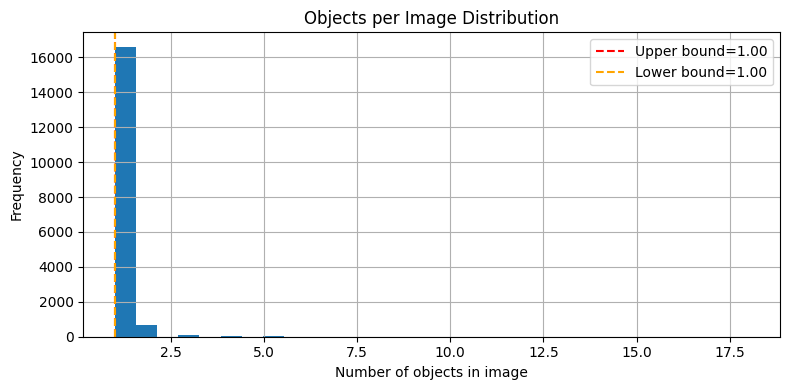

In [7]:
# 2) Per-image object count and outlier inspection

if ann_df.empty:
    print("No annotations available for per-image object count analysis.")
else:
    per_image_counts = ann_df.groupby(["split", "image"]).size().reset_index(name="num_objects")
    display(per_image_counts.describe(include="all"))

    q1 = per_image_counts["num_objects"].quantile(0.25)
    q3 = per_image_counts["num_objects"].quantile(0.75)
    iqr = q3 - q1
    lower_bound = max(0, q1 - 1.5 * iqr)
    upper_bound = q3 + 1.5 * iqr

    outliers = per_image_counts[
        (per_image_counts["num_objects"] < lower_bound)
        | (per_image_counts["num_objects"] > upper_bound)
    ].sort_values("num_objects", ascending=False)

    print(f"Outlier bounds (IQR): [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Outlier images found: {len(outliers)}")
    display(outliers.head(20))

    plt.figure(figsize=(8, 4))
    per_image_counts["num_objects"].hist(bins=30)
    plt.axvline(upper_bound, color="red", linestyle="--", label=f"Upper bound={upper_bound:.2f}")
    plt.axvline(lower_bound, color="orange", linestyle="--", label=f"Lower bound={lower_bound:.2f}")
    plt.title("Objects per Image Distribution")
    plt.xlabel("Number of objects in image")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


,class_id,class_name,count,percentage
0,0,gun,18807,100.0


Imbalance ratio (max/min): 1.00


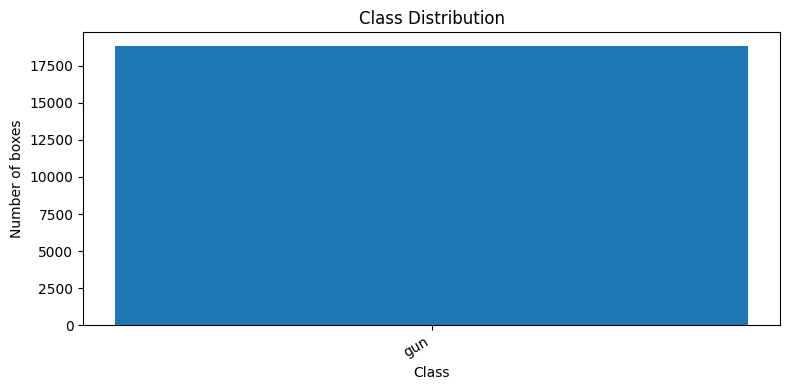

In [8]:
# 1) Class imbalance check (future-proof for multi-class datasets)
if ann_df.empty:
    print("No annotations available to analyze class imbalance.")
else:
    class_counts = ann_df["class_id"].value_counts().sort_index()
    class_dist = pd.DataFrame({
        "class_id": class_counts.index,
        "count": class_counts.values
    })
    class_dist["class_name"] = class_dist["class_id"].apply(
        lambda cid: class_names[cid] if cid < len(class_names) else f"class_{cid}"
    )
    class_dist["percentage"] = 100 * class_dist["count"] / class_dist["count"].sum()

    display(class_dist[["class_id", "class_name", "count", "percentage"]])

    imbalance_ratio = class_dist["count"].max() / class_dist["count"].min()
    print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

    plt.figure(figsize=(8, 4))
    plt.bar(class_dist["class_name"], class_dist["count"])
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of boxes")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## YOLO26 Training

The next cells train a YOLO26 detector with the nano checkpoint (`yolo26n.pt`) as a fast baseline. Increase `EPOCHS` or switch to `yolo26s.pt` / `yolo26m.pt` if you want a stronger run and have more time.


Model weights: yolo26n.pt
Device: mps
Batch size: 8
Epochs: 20
Image size: 640
Training fraction: 1.0
Data config: /Users/gubscruz/INSPER/7_PERIODO/computer-vision/cv-gun-detection/data/Gun.v2i.yolo26/data_yolo26_local.yaml
